In [1]:
import pandas as pd

In [2]:
embedding_dims = 32
random_state = 2020
train_test_split = (
    0.3  # needs to use the same as 06.01-triplet-loss.ipynb for consistent split
)
dataset_training_frac = (
    1  # needs to use the same as 06.01-triplet-loss.ipynb for consistent split
)
test_samples = 18000  # t-SNE can be slow. lower this for small tests

#### Objective:

Visualize and evaluate generated embeddings for transactions in the test set.

#### Depends on:

In [ ]:
df_fname = "./data/05-dataframe-with-vectors.parquet"
triplet_loss_model_fname = "./data/triplet_loss_model_4_agencies.pth"

------------

In [3]:
df = pd.read_parquet(df_fname)  # this takes 4GB

In [4]:
# DEPARTMENT OF TRANSPORTATION|34500
# DEPARTMENT OF CORRECTIONS|13100
# DEPARTMENT OF TOURISM AND RECREATION|56600
# DEPARTMENT OF VETERANS AFFAIRS|65000

df = df[df.agency_number.isin([34500, 13100, 56600, 65000])]

In [5]:
df = df.sample(frac=dataset_training_frac, random_state=random_state)

In [6]:
drop_cols = [
    "cohort",
    "agency_name",
    "holder_last_name",
    "holder_first_initial",
    "amount",
    "vendor",
    "mcc",
    "posted_date",
]  # keep 'transaction_date', 'agency_number', 'parsed_amount' and repr of mcc and vendor
label_col = "agency_number"

In [7]:
df.drop(drop_cols, axis=1, inplace=True)

In [8]:
input_dim = (
    len(df.columns) - 2
)  # 'transaction_date', 'agency_number' will not go into the model

In [9]:
import torch
import numpy as np
import random
from sklearn import model_selection
import torch.nn as nn
from tqdm.notebook import tqdm

In [10]:
torch.manual_seed(random_state)
np.random.seed(random_state)
random.seed(random_state)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.get_device_name()

In [11]:
class EmbeddingModel(nn.Module):
    def __init__(self, input_dim=1537, emb_dim=32):
        super(EmbeddingModel, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.PReLU(),
            nn.Linear(input_dim, 1024),
            nn.PReLU(),
            nn.Linear(1024, 1024),
            nn.PReLU(),
            nn.Linear(1024, 128),
            nn.PReLU(),
            nn.Linear(128, 64),
            nn.PReLU(),
            nn.Linear(64, 64),
            nn.PReLU(),
            nn.Linear(64, emb_dim),
        )

    def forward(self, x):
        x = self.fc(x)
        return x

In [12]:
emb_model = EmbeddingModel(input_dim, embedding_dims)

In [13]:
emb_model.load_state_dict(torch.load(triplet_loss_model_fname))

<All keys matched successfully>

In [14]:
emb_model.eval()

EmbeddingModel(
  (fc): Sequential(
    (0): Linear(in_features=1537, out_features=1537, bias=True)
    (1): PReLU(num_parameters=1)
    (2): Linear(in_features=1537, out_features=1024, bias=True)
    (3): PReLU(num_parameters=1)
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): PReLU(num_parameters=1)
    (6): Linear(in_features=1024, out_features=128, bias=True)
    (7): PReLU(num_parameters=1)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): PReLU(num_parameters=1)
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): PReLU(num_parameters=1)
    (12): Linear(in_features=64, out_features=32, bias=True)
  )
)

In [15]:
with torch.no_grad():
    sample = (
        df.sample(1)
        .drop(["transaction_date", "agency_number"], axis=1)
        .values.astype("float32")
    )
    sample_embedding = emb_model(torch.from_numpy(sample).cpu()).cpu().numpy()

sample_embedding

array([[-0.80025744,  0.23363054, -0.659636  , -0.5503477 ,  0.8248619 ,
        -0.27629915, -0.49909252, -0.6003041 , -0.3779326 , -0.250773  ,
         0.3019688 ,  0.85208905,  0.530582  , -0.59141856, -0.22164339,
         0.6335025 , -0.68889266,  0.82229567, -0.0647141 ,  0.8168065 ,
         1.0790865 , -1.098988  ,  0.2723695 , -0.10384429,  0.7858063 ,
         0.16124612, -0.32642353,  0.17262109,  0.8197931 , -0.20304626,
         0.10226808, -0.20527919]], dtype=float32)

In [16]:
_, X_test = model_selection.train_test_split(
    df, test_size=train_test_split, random_state=random_state
)

In [17]:
import matplotlib
from matplotlib import pyplot as plt

matplotlib.use("nbagg")

In [18]:
emb_model.eval()
with torch.no_grad():
    X = X_test.drop(["transaction_date", "agency_number"], axis=1).values[:test_samples]
    labels = X_test["agency_number"].values[:test_samples]

    pred = emb_model(torch.from_numpy(X.astype("float32")).cpu()).cpu().numpy()

In [19]:
len(labels)

18000

In [20]:
pred.shape

(18000, 32)

In [21]:
from sklearn.manifold import TSNE

In [54]:
embedded = TSNE(
    n_components=2,
    learning_rate="auto",
    init="random",
    random_state=random_state,
    perplexity=50,
).fit_transform(pred)

In [55]:
embedded.shape

(18000, 2)

In [56]:
np.unique(labels)

array([13100, 34500, 56600, 65000])

In [57]:
# colors = random.sample(k=len(np.unique(labels)), population=["cloudy blue","dark pastel green","dust","electric lime","fresh green","light eggplant","nasty green","really light blue","tea","warm purple","yellowish tan","cement","dark grass green","dusty teal","grey teal","macaroni and cheese","pinkish tan","spruce","strong blue","toxic green","windows blue","blue blue","blue with a hint of purple","booger","bright sea green","dark green blue","deep turquoise","green teal","strong pink","bland","deep aqua","lavender pink","light moss green","light seafoam green","olive yellow","pig pink","deep lilac","desert","dusty lavender","purpley grey","purply","candy pink","light pastel green","boring green","kiwi green","light grey green","orange pink","tea green","very light brown","egg shell","eggplant purple","powder pink","reddish grey","baby shit brown","liliac","stormy blue","ugly brown","custard","darkish pink","deep brown","greenish beige","manilla","off blue","battleship grey","browny green","bruise","kelley green","sickly yellow","sunny yellow","azul","darkgreen","green/yellow","lichen","light light green","pale gold","sun yellow","tan green","burple","butterscotch","toupe","dark cream","indian red","light lavendar","poison green","baby puke green","bright yellow green","charcoal grey","squash","cinnamon","light pea green","radioactive green","raw sienna","baby purple","cocoa","light royal blue","orangeish","rust brown","sand brown","swamp","tealish green","burnt siena","camo","dusk blue","fern","old rose","pale light green","peachy pink","rosy pink","light bluish green","light bright green","light neon green","light seafoam","tiffany blue","washed out green","browny orange","nice blue","sapphire","greyish teal","orangey yellow","parchment","straw","very dark brown","terracota","ugly blue","clear blue","creme","foam green","grey/green","light gold","seafoam blue","topaz","violet pink","wintergreen","yellow tan","dark fuchsia","indigo blue","light yellowish green","pale magenta","rich purple","sunflower yellow","green/blue","leather","racing green","vivid purple","dark royal blue","hazel","muted pink","booger green","canary","cool grey","dark taupe","darkish purple","true green","coral pink","dark sage","dark slate blue","flat blue","mushroom","rich blue","dirty purple","greenblue","icky green","light khaki","warm blue","dark hot pink","deep sea blue","carmine","dark yellow green","pale peach","plum purple","golden rod","neon red","old pink","very pale blue","blood orange","grapefruit","sand yellow","clay brown","dark blue grey","flat green","light green blue","warm pink","dodger blue","gross green","ice","metallic blue","pale salmon","sap green","algae","bluey grey","greeny grey","highlighter green","light light blue","light mint","raw umber","vivid blue","deep lavender","dull teal","light greenish blue","mud green","pinky","red wine","shit green","tan brown","darkblue","rosa","lipstick","pale mauve","claret","dandelion","orangered","poop green","ruby","dark","greenish turquoise","pastel red","piss yellow","bright cyan","dark coral","algae green","darkish red","reddy brown","blush pink","camouflage green","lawn green","putty","vibrant blue","dark sand","purple/blue","saffron","twilight","warm brown","bluegrey","bubble gum pink","duck egg blue","greenish cyan","petrol","royal","butter","dusty orange","off yellow","pale olive green","orangish","leaf","light blue grey","dried blood","lightish purple","rusty red","lavender blue","light grass green","light mint green","sunflower","velvet","brick orange","lightish red","pure blue","twilight blue","violet red","yellowy brown","carnation","muddy yellow","dark seafoam green","deep rose","dusty red","grey/blue","lemon lime","purple/pink","brown yellow","purple brown","wisteria","banana yellow","lipstick red","water blue","brown grey","vibrant purple","baby green","barf green","eggshell blue","sandy yellow","cool green","pale","blue/grey","hot magenta","greyblue","purpley","baby shit green","brownish pink","dark aquamarine","diarrhea","light mustard","pale sky blue","turtle green","bright olive","dark grey blue","greeny brown","lemon green","light periwinkle","seaweed green","sunshine yellow","ugly purple","medium pink","puke brown","very light pink","viridian","bile","faded yellow","very pale green","vibrant green","bright lime","spearmint","light aquamarine","light sage","yellowgreen","baby poo","dark seafoam","deep teal","heather","rust orange","dirty blue","fern green","bright lilac","weird green","peacock blue","avocado green","faded orange","grape purple","hot green","lime yellow","mango","shamrock","bubblegum","purplish brown","vomit yellow","pale cyan","key lime","tomato red","lightgreen","merlot","night blue","purpleish pink","apple","baby poop green","green apple","heliotrope","yellow/green","almost black","cool blue","leafy green","mustard brown","dusk","dull brown","frog green","vivid green","bright light green","fluro green","kiwi","seaweed","navy green","ultramarine blue","iris","pastel orange","yellowish orange","perrywinkle","tealish","dark plum","pear","pinkish orange","midnight purple","light urple","dark mint","greenish tan","light burgundy","turquoise blue","ugly pink","sandy","electric pink","muted purple","mid green","greyish","neon yellow","banana","carnation pink","tomato","sea","muddy brown","turquoise green","buff","fawn","muted blue","pale rose","dark mint green","amethyst","blue/green","chestnut","sick green","pea","rusty orange","stone","rose red","pale aqua","deep orange","earth","mossy green","grassy green","pale lime green","light grey blue","pale grey","asparagus","blueberry","purple red","pale lime","greenish teal","caramel","deep magenta","light peach","milk chocolate","ocher","off green","purply pink","lightblue","dusky blue","golden","light beige","butter yellow","dusky purple","french blue","ugly yellow","greeny yellow","orangish red","shamrock green","orangish brown","tree green","deep violet","gunmetal","blue/purple","cherry","sandy brown","warm grey","dark indigo","midnight","bluey green","grey pink","soft purple","blood","brown red","medium grey","berry","poo","purpley pink","light salmon","snot","easter purple","light yellow green","dark navy blue","drab","light rose","rouge","purplish red","slime green","baby poop","irish green","pink/purple","dark navy","greeny blue","light plum","pinkish grey","dirty orange","rust red","pale lilac","orangey red","primary blue","kermit green","brownish purple","murky green","wheat","very dark purple","bottle green","watermelon","deep sky blue","fire engine red","yellow ochre","pumpkin orange","pale olive","light lilac","lightish green","carolina blue","mulberry","shocking pink","auburn","bright lime green","celadon","pinkish brown","poo brown","bright sky blue","celery","dirt brown","strawberry","dark lime","copper","medium brown","muted green","robin's egg","bright aqua","bright lavender","ivory","very light purple","light navy","pink red","olive brown","poop brown","mustard green","ocean green","very dark blue","dusty green","light navy blue","minty green","adobe","barney","jade green","bright light blue","light lime","dark khaki","orange yellow","ocre","maize","faded pink","british racing green","sandstone","mud brown","light sea green","robin egg blue","aqua marine","dark sea green","soft pink","orangey brown","cherry red","burnt yellow","brownish grey","camel","purplish grey","marine","greyish pink","pale turquoise","pastel yellow","bluey purple","canary yellow","faded red","sepia","coffee","bright magenta","mocha","ecru","purpleish","cranberry","darkish green","brown orange","dusky rose","melon","sickly green","silver","purply blue","purpleish blue","hospital green","shit brown","mid blue","amber","easter green","soft blue","cerulean blue","golden brown","bright turquoise","red pink","red purple","greyish brown","vermillion","russet","steel grey","lighter purple","bright violet","prussian blue","slate green","dirty pink","dark blue green","pine","yellowy green","dark gold","bluish","darkish blue","dull red","pinky red","bronze","pale teal","military green","barbie pink","bubblegum pink","pea soup green","dark mustard","shit","medium purple","very dark green","dirt","dusky pink","red violet","lemon yellow","pistachio","dull yellow","dark lime green","denim blue","teal blue","lightish blue","purpley blue","light indigo","swamp green","brown green","dark maroon","hot purple","dark forest green","faded blue","drab green","light lime green","snot green","yellowish","light blue green","bordeaux","light mauve","ocean","marigold","muddy green","dull orange","steel","electric purple","fluorescent green","yellowish brown","blush","soft green","bright orange","lemon","purple grey","acid green","pale lavender","violet blue","light forest green","burnt red","khaki green","cerise","faded purple","apricot","dark olive green","grey brown","green grey","true blue","pale violet","periwinkle blue","light sky blue","blurple","green brown","bluegreen","bright teal","brownish yellow","pea soup","forest","barney purple","ultramarine","purplish","puke yellow","bluish grey","dark periwinkle","dark lilac","reddish","light maroon","dusty purple","terra cotta","avocado","marine blue","teal green","slate grey","lighter green","electric green","dusty blue","golden yellow","bright yellow","light lavender","umber","poop","dark peach","jungle green","eggshell","denim","yellow brown","dull purple","chocolate brown","wine red","neon blue","dirty green","light tan","ice blue","cadet blue","dark mauve","very light blue","grey purple","pastel pink","very light green","dark sky blue","evergreen","dull pink","aubergine","mahogany","reddish orange","deep green","vomit green","purple pink","dusty pink","faded green","camo green","pinky purple","pink purple","brownish red","dark rose","mud","brownish","emerald green","pale brown","dull blue","burnt umber","medium green","clay","light aqua","light olive green","brownish orange","dark aqua","purplish pink","dark salmon","greenish grey","jade","ugly green","dark beige","emerald","pale red","light magenta","sky","light cyan","yellow orange","reddish purple","reddish pink","orchid","dirty yellow","orange red","deep red","orange brown","cobalt blue","neon pink","rose pink","greyish purple","raspberry","aqua green","salmon pink","tangerine","brownish green","red brown","greenish brown","pumpkin","pine green","charcoal","baby pink","cornflower","blue violet","chocolate","greyish green","scarlet","green yellow","dark olive","sienna","pastel purple","terracotta","aqua blue","sage green","blood red","deep pink","grass","moss","pastel blue","bluish green","green blue","dark tan","greenish blue","pale orange","vomit","forrest green","dark lavender","dark violet","purple blue","dark cyan","olive drab","pinkish","cobalt","neon purple","light turquoise","apple green","dull green","wine","powder blue","off white","electric blue","dark turquoise","blue purple","azure","bright red","pinkish red","cornflower blue","light olive","grape","greyish blue","purplish blue","yellowish green","greenish yellow","medium blue","dusty rose","light violet","midnight blue","bluish purple","red orange","dark magenta","greenish","ocean blue","coral","cream","reddish brown","burnt sienna","brick","sage","grey green","white","robin's egg blue","moss green","steel blue","eggplant","light yellow","leaf green","light grey","puke","pinkish purple","sea blue","pale purple","slate blue","blue grey","hunter green","fuchsia","crimson","pale yellow","ochre","mustard yellow","light red","cerulean","pale pink","deep blue","rust","light teal","slate","goldenrod","dark yellow","dark grey","army green","grey blue","seafoam","puce","spring green","dark orange","sand","pastel green","mint","light orange","bright pink","chartreuse","deep purple","dark brown","taupe","pea green","puke green","kelly green","seafoam green","blue green","khaki","burgundy","dark teal","brick red","royal purple","plum","mint green","gold","baby blue","yellow green","bright purple","dark red","pale blue","grass green","navy","aquamarine","burnt orange","neon green","bright blue","rose","light pink","mustard","indigo","lime","sea green","periwinkle","dark pink","olive green","peach","pale green","light brown","hot pink","black","lilac","navy blue","royal blue","beige","salmon","olive","maroon","bright green","dark purple","mauve","forest green","aqua","cyan","tan","dark blue","lavender","turquoise","dark green","violet","light purple","lime green","grey","sky blue","yellow","magenta","light green","orange","teal","light blue","red","brown","pink","blue","green","purple"])

In [58]:
# color_map = {agency: color for agency, color in zip(np.unique(labels), colors)

In [59]:
# color_map

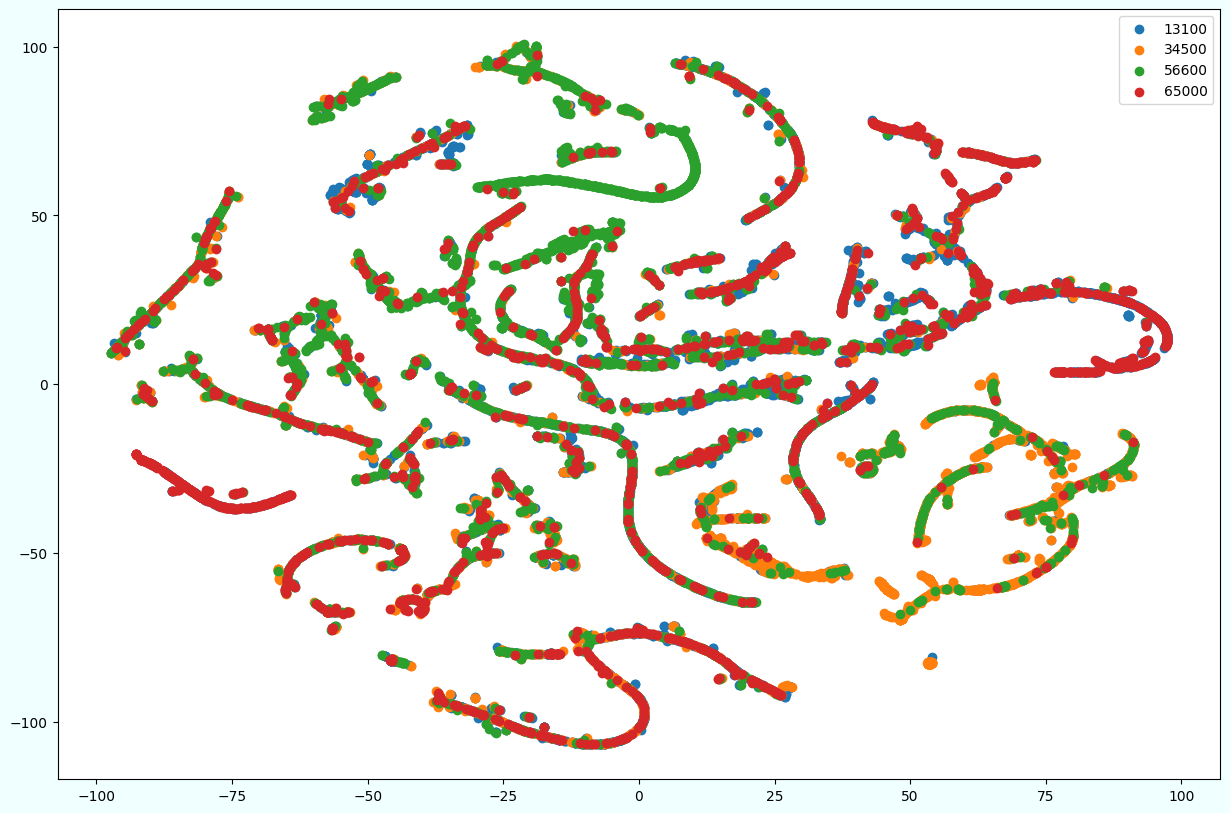

In [60]:
%matplotlib inline
plt.figure(figsize=(15, 10), facecolor="azure")

for label in np.unique(labels):
    emb_for_label = embedded[labels == label]
    plt.scatter(emb_for_label[:, 0], emb_for_label[:, 1], label=label)

plt.legend()
plt.show()

In [61]:
pred

array([[-0.8002573 ,  0.2336306 , -0.65963584, ..., -0.20304632,
         0.10226803, -0.20527929],
       [-0.48419008,  0.5274744 , -0.61204064, ..., -0.1446631 ,
         0.08877689, -0.1749846 ],
       [-0.7555054 ,  0.49828106, -0.7571991 , ..., -0.19302268,
         0.15609731, -0.2039298 ],
       ...,
       [-0.834162  ,  0.7386904 , -0.9678402 , ..., -0.22360964,
         0.19262184, -0.24447803],
       [-0.6198292 ,  0.74708855, -0.8442346 , ..., -0.17973235,
         0.13636729, -0.23256668],
       [-1.1417067 ,  0.5826013 , -1.0733513 , ..., -0.2848505 ,
         0.23201412, -0.2804749 ]], dtype=float32)

In [62]:
emb_for_label[:, 0][:5]

array([ 91.06638  , -79.965164 ,  -6.8196697,  -2.099806 ,  10.572799 ],
      dtype=float32)

In [63]:
emb_for_label[:, 1][:5]

array([-17.225527  ,   0.25111175,  14.891264  , -73.72555   ,
        36.609722  ], dtype=float32)

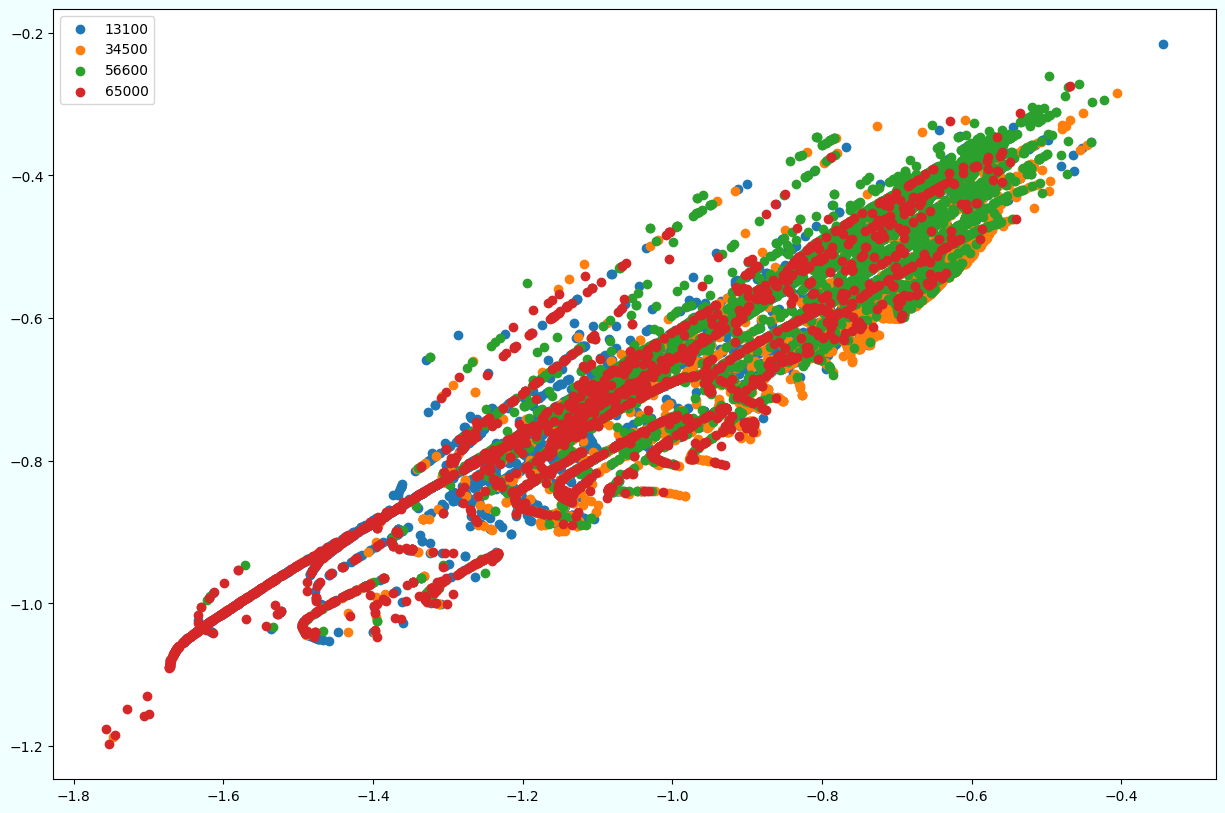

In [64]:
%matplotlib inline
plt.figure(figsize=(15, 10), facecolor="azure")

for label in np.unique(labels):
    emb_for_label = pred[labels == label]
    plt.scatter(emb_for_label[:, 2], emb_for_label[:, 3], label=label)

plt.legend()
plt.show()

In [68]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [67]:
calinski_harabasz_score(pred, labels)

1943.4535875524068

In [69]:
davies_bouldin_score(pred, labels)

3.6563475866036406